# HW 1 Guide E: Testing the CAPM and the Three-Factor Model

Two readings tell the theory story:
[From Mean-Variance to the CAPM](https://finm-32800.github.io/notebooks/_07_mean_variance_to_CAPM_ipynb.html)
and
[From the CAPM to Multifactor Models](https://finm-32800.github.io/notebooks/_08_CAPM_to_multifactor_models_ipynb.html).
The CAPM says the market is the tangency portfolio from HW 0. Multifactor
models, such as Fama and French (1993), say the tangency portfolio is a mix
of the market, SMB, and HML. This notebook puts both claims to the data,
using the portfolios the HW 1 pipeline builds:

1. **6 size and book-to-market portfolios** (`FF_1993_vwret.parquet`), the
   2x3 sort from Fama and French (1993).
2. **3 investment portfolios** (`univ_3_inv_vwret.parquet`), sorted on asset
   growth into conservative (Low), Medium, and aggressive (High).

Each claim can be checked two equivalent ways:

- **As a portfolio problem.** Is the market (or the mix of Mkt-RF, SMB, and
  HML) the tangency portfolio? If so, no other portfolio can raise its
  Sharpe ratio.
- **As a regression.** Regress each portfolio's excess return on the
  factors. If the model holds, the intercept, alpha, is zero:

$$
R_{p,t} - R_{f,t} = \alpha_p + \beta_{p} (R_{m,t} - R_{f,t})
  + s_p \, SMB_t + h_p \, HML_t + \varepsilon_{p,t}.
$$

The CAPM is this regression with $s_p = h_p = 0$. A nonzero alpha means that
the factors' tangency portfolio can be improved on by adding portfolio $p$
(Gibbons, Ross, and Shanken 1989), so the two views always agree.

The calculations are in `src/calc_CAPM_and_FF3.py`, and the `doit` task
`calc_CAPM_and_FF3` saves the tables this guide discusses. In HW 1 this part
has no blanks to fill and no tests: it is here to show what the portfolios
you built in Part D are for.

In [1]:
import calc_CAPM_and_FF3
import figures
from settings import config

DATA_DIR = config("DATA_DIR")
OUTPUT_DIR = config("OUTPUT_DIR")

## Load the data

The portfolio returns come from the HW 1 pipeline. The market factor, SMB,
HML, and the risk-free rate are Ken French's official series
(`FF_FACTORS.parquet`). Excess returns subtract the risk-free rate.

In [2]:
portfolios, factors, excess_returns = calc_CAPM_and_FF3.load_test_assets(
    data_dir=DATA_DIR
)
tables = calc_CAPM_and_FF3.load_tables(output_dir=OUTPUT_DIR)

print(
    f"{len(excess_returns)} months, {excess_returns.index.min():%Y-%m} to {excess_returns.index.max():%Y-%m}"
)
excess_returns.head()

690 months, 1967-07 to 2024-12


,SL,SME,SH,BL,BME,BH,Low,Medium,High
jdate,,,,,,,,,
1967-07-31,0.059197,0.066041,0.096480,0.046555,0.028994,0.069242,0.055290,0.030918,0.057613
1967-08-31,-0.005925,-0.008742,0.001396,-0.011248,-0.015236,0.009736,-0.021376,-0.010249,-0.008022
1967-09-30,0.054902,0.036981,0.046046,0.036723,0.019407,0.017920,0.014593,0.035391,0.020449
1967-10-31,-0.020694,-0.029065,-0.039934,-0.016809,-0.044634,-0.052199,-0.040570,-0.031605,-0.023826
1967-11-30,0.010628,0.005021,-0.015107,0.007192,0.000413,-0.005694,-0.008637,0.007597,0.002894


## From HW 0 to the CAPM: is the market the tangency portfolio?

HW 0 derived the tangency portfolio, the risky portfolio with the highest
Sharpe ratio. With excess returns, its weights are proportional to
$\Sigma^{-1}\mu$, rescaled to sum to one. The CAPM says that the market alone
is that portfolio. The three-factor model says that the tangency portfolio
is a mix of Mkt-RF, SMB, and HML.

SMB and HML are long-short portfolios, so a "weight" here is the size of the
position in each factor per dollar in the market.

The calculation is short enough to show in full:

```python
def tangency(excess):
    w = np.linalg.solve(excess.cov(), excess.mean())
    w = pd.Series(w / w.sum(), index=excess.columns)
    portfolio = excess @ w
    sharpe = portfolio.mean() / portfolio.std() * np.sqrt(12)
    return w, sharpe
```

In [3]:
tables["tangency"].round(2)

,Sharpe ratio (annual),Mkt-RF,SMB,HML
Market alone,0.44,1.00,NaN,NaN
Mkt + SMB + HML,0.61,0.42,0.05,0.53


The mix of the three factors reaches a noticeably higher Sharpe ratio than
the market alone. In mean-variance terms, that is the whole case against the
CAPM: the market is not on the efficient frontier, because tilting toward
small and value stocks improves it. The chart shows the same thing. Each
line starts at zero excess return (the risk-free asset) and its slope is a
Sharpe ratio, as in HW 0.

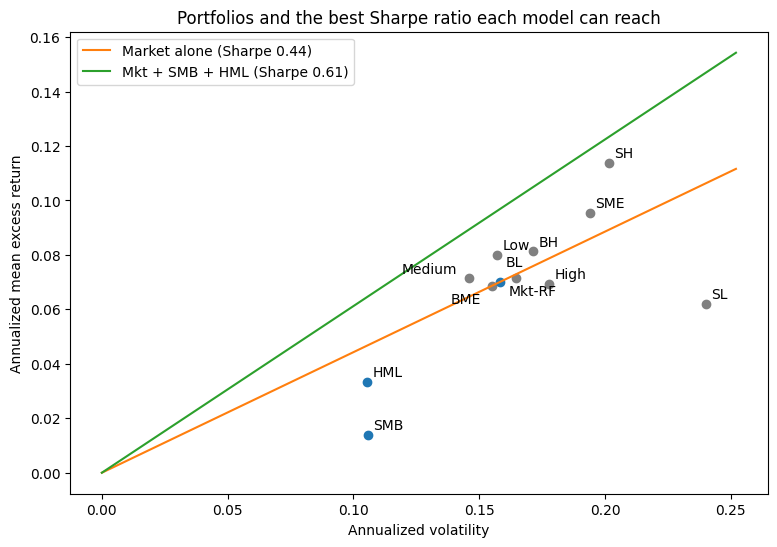

In [4]:
fig = figures.plot_sharpe_lines(excess_returns, factors, tables["tangency"])

## The CAPM regressions

Now the regression view, one portfolio at a time. For each portfolio we
report the annualized alpha, its t-statistic, the market beta, and the
R-squared. If the CAPM holds, every alpha is zero; a |t| above about 2 means
the data reject that for that portfolio.

In [5]:
tables["capm"].round(3)

,Alpha (annual),t(Alpha),Beta Mkt-RF,R-squared
SL,-0.031,-1.986,1.325,0.764
SME,0.020,1.619,1.079,0.776
SH,0.039,2.662,1.062,0.696
BL,0.001,0.162,1.010,0.942
BME,0.004,0.581,0.916,0.874
BH,0.016,1.382,0.928,0.736
Low,0.014,2.081,0.941,0.899
Medium,0.009,1.837,0.892,0.939
High,-0.007,-1.416,1.095,0.950


Market betas range from about 0.9 to 1.3, and the market explains most of
the variance of every portfolio, but the alphas are not all zero. Small value stocks (SH) earn much
more than their beta predicts and small growth stocks (SL) earn less. Among
the investment portfolios, conservative firms (Low) earn more than their beta
predicts. These are the patterns Fama and French set out to explain.

## Adding SMB and HML

The same regressions with SMB and HML added:

In [6]:
tables["ff3"].round(3)

,Alpha (annual),t(Alpha),Beta Mkt-RF,Beta SMB,Beta HML,R-squared
SL,-0.021,-4.165,1.091,1.043,-0.228,0.975
SME,0.004,0.938,0.974,0.808,0.366,0.977
SH,0.008,2.591,0.998,0.855,0.719,0.987
BL,0.013,4.013,0.999,-0.150,-0.281,0.978
BME,-0.010,-1.819,0.984,-0.111,0.329,0.930
BH,-0.017,-3.096,1.044,-0.043,0.757,0.946
Low,0.006,0.916,0.962,0.032,0.189,0.914
Medium,0.001,0.385,0.944,-0.144,0.173,0.966
High,0.000,0.073,1.066,0.013,-0.180,0.962


### Reading the factor loadings

The loadings on SMB and HML describe what each portfolio looks like:

- **SMB loading above zero:** the portfolio behaves like small stocks.
  Below zero, like large stocks.
- **HML loading above zero:** the portfolio behaves like value stocks (high
  book-to-market). Below zero, like growth stocks (low book-to-market).

The loadings line up with how the portfolios were sorted. The three small
portfolios load heavily on SMB, the two high book-to-market portfolios load
positively on HML, and the two low book-to-market portfolios load
negatively. The investment portfolios have almost no size tilt, but the
conservative portfolio leans toward value and the aggressive one toward
growth.

## What the three factors do and do not fix

Put the two models side by side.

In [7]:
tables["alpha_comparison"].round(3)

,CAPM alpha,CAPM t,FF3 alpha,FF3 t,CAPM R2,FF3 R2
SL,-0.031,-1.986,-0.021,-4.165,0.764,0.975
SME,0.020,1.619,0.004,0.938,0.776,0.977
SH,0.039,2.662,0.008,2.591,0.696,0.987
BL,0.001,0.162,0.013,4.013,0.942,0.978
BME,0.004,0.581,-0.010,-1.819,0.874,0.930
BH,0.016,1.382,-0.017,-3.096,0.736,0.946
Low,0.014,2.081,0.006,0.916,0.899,0.914
Medium,0.009,1.837,0.001,0.385,0.939,0.966
High,-0.007,-1.416,0.000,0.073,0.950,0.962


In [8]:
tables["model_summary"].round(3)

,CAPM,FF3
Mean |alpha| (annual),0.016,0.009
Mean R-squared,0.842,0.959
Portfolios with |t| > 1.96,3.000,4.000


Adding SMB and HML does what the theory hopes in two ways. R-squared rises
for every portfolio, and the typical alpha shrinks, most dramatically for
small value stocks. It does *not* make the model pass. Because the three
factors explain almost all of the variance, the remaining alphas are
measured very precisely, and several are still clearly nonzero. More
portfolios have a significant alpha under FF3 than under the CAPM:

- **Small growth (SL)** still earns too little. This is the best-known
  failure of the three-factor model.
- **Big value and big growth (BH, BL)** get alphas of opposite sign. HML
  averages the value premium across small and big stocks, but the premium is
  much larger among small stocks, so a single HML loading overstates it for
  big stocks.

In mean-variance language, the tangency portfolio of Mkt, SMB, and HML is
much better than the market alone, but it is still not the true tangency
portfolio of these nine portfolios.

## The investment portfolios

Under the CAPM, conservative firms (Low) earn a positive alpha and
aggressive firms (High) a negative one. The three-factor model absorbs most
of that spread through HML: conservative firms tend to be value firms, and
aggressive firms tend to be growth firms.

In [9]:
tables["investment_spread"].round(4)

,CAPM,FF3
"Alpha, Low minus High investment (annual)",0.0213,0.0053


If a significant Low-minus-High alpha spread had survived the three-factor
adjustment, that would suggest investment is a distinct priced factor. With
only three coarse portfolios, HML absorbs most of it here. Finer sorts, such
as the 25 size-investment portfolios, do leave investment and profitability
alphas that the three factors miss. That is why Fama and French (2015) add
**CMA** (conservative minus aggressive investment) and **RMW** (robust minus
weak profitability) in their five-factor model. In that model, HML becomes
largely redundant, which matches what the investment portfolios show above.

## Summary

- The market alone is not the tangency portfolio. Mixing in SMB and HML
  raises the maximum Sharpe ratio, which is the same fact as the CAPM alphas
  seen through a regression.
- The three-factor model raises R-squared and shrinks alphas, but the
  remaining alphas (small growth, and big value versus big growth) are
  precise enough to reject it.
- The investment effect in three portfolios is mostly an HML tilt. Finer
  sorts are what motivated the five-factor model.

## References

- Fama, Eugene F., and Kenneth R. French. "Common Risk Factors in the Returns
  on Stocks and Bonds." *Journal of Financial Economics* 33, no. 1 (1993):
  3-56.
- Fama, Eugene F., and Kenneth R. French. "A Five-Factor Asset Pricing
  Model." *Journal of Financial Economics* 116, no. 1 (2015): 1-22.
- Gibbons, Michael R., Stephen A. Ross, and Jay Shanken. "A Test of the
  Efficiency of a Given Portfolio." *Econometrica* 57, no. 5 (1989):
  1121-1152.